In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [4]:
ds = pd.read_csv('healthcare_denials_finalDT.csv')
ds.head(3)

,claim_id,patient_age_years,patient_gender,payer_id,insurance_plan_type,is_in_network,procedure_code_cpt,primary_diagnosis_code_icd10,provider_specialty,facility_type,prior_auth_required,billed_amount_usd,days_between_service_and_submission,prior_auth_status,is_claim_denied,denial_reason_code
0,CLM-7949297,49,Male,PAYER_B,HMO,No,99214,F32.9,Orthopedic Surgery,Skilled Nursing Facility,No,247.60,109,Not Required,1,Timely Filing
1,CLM-5284778,24,Female,PAYER_B,POS,Yes,93000,F32.9,Cardiology,Outpatient Clinic,Yes,219.21,75,Denied,1,Lack of Prior Auth
2,CLM-1318356,67,Male,PAYER_D,EPO,Yes,93000,N39.0,Internal Medicine,Ambulatory Surgery Center,Yes,1334.56,107,Approved,0,NaN


In [5]:
ds.shape

(15000, 16)

In [6]:
ds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 16 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   claim_id                             15000 non-null  object 
 1   patient_age_years                    15000 non-null  int64  
 2   patient_gender                       15000 non-null  object 
 3   payer_id                             15000 non-null  object 
 4   insurance_plan_type                  15000 non-null  object 
 5   is_in_network                        15000 non-null  object 
 6   procedure_code_cpt                   15000 non-null  object 
 7   primary_diagnosis_code_icd10         15000 non-null  object 
 8   provider_specialty                   15000 non-null  object 
 9   facility_type                        15000 non-null  object 
 10  prior_auth_required                  15000 non-null  object 
 11  billed_amount_usd           

In [7]:
ds.isnull().sum()

claim_id                                   0
patient_age_years                          0
patient_gender                             0
payer_id                                   0
insurance_plan_type                        0
is_in_network                              0
procedure_code_cpt                         0
primary_diagnosis_code_icd10               0
provider_specialty                         0
facility_type                              0
prior_auth_required                        0
billed_amount_usd                          0
days_between_service_and_submission        0
prior_auth_status                          0
is_claim_denied                            0
denial_reason_code                     10596
dtype: int64

In [8]:
ds.duplicated().sum()

0

In [9]:
ds = ds.rename(columns={'is_claim_denied': 'claim_status'})

In [10]:
ds.head()

,claim_id,patient_age_years,patient_gender,payer_id,insurance_plan_type,is_in_network,procedure_code_cpt,primary_diagnosis_code_icd10,provider_specialty,facility_type,prior_auth_required,billed_amount_usd,days_between_service_and_submission,prior_auth_status,claim_status,denial_reason_code
0,CLM-7949297,49,Male,PAYER_B,HMO,No,99214,F32.9,Orthopedic Surgery,Skilled Nursing Facility,No,247.60,109,Not Required,1,Timely Filing
1,CLM-5284778,24,Female,PAYER_B,POS,Yes,93000,F32.9,Cardiology,Outpatient Clinic,Yes,219.21,75,Denied,1,Lack of Prior Auth
2,CLM-1318356,67,Male,PAYER_D,EPO,Yes,93000,N39.0,Internal Medicine,Ambulatory Surgery Center,Yes,1334.56,107,Approved,0,NaN
3,CLM-8533157,87,Female,PAYER_C,PPO,Yes,99213,N39.0,Oncology,Emergency Room,Yes,2593.11,108,Approved,0,NaN
4,CLM-4317601,73,Female,PAYER_A,HMO,Yes,99214,E11.9,Oncology,Inpatient Hospital,No,6082.16,155,Not Required,0,NaN


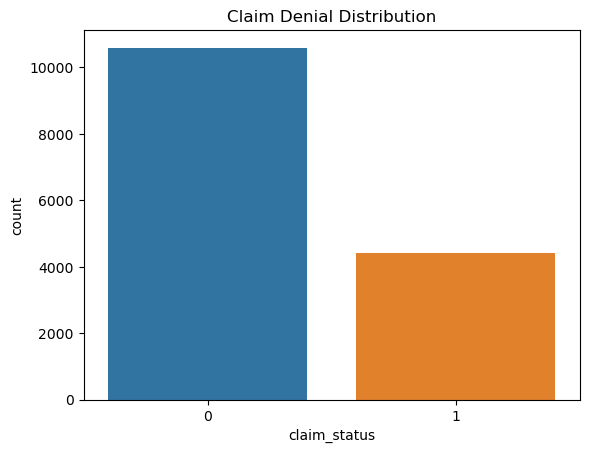

In [11]:
#Target variable distribution
sns.countplot(x='claim_status', data=ds)
plt.title("Claim Denial Distribution")
plt.show()
# Its important for : it helps to decide class balancing or not

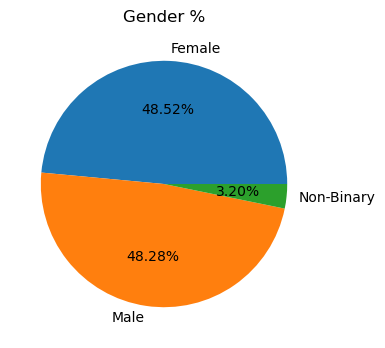

In [12]:
#Gender Distribution
fig = plt.figure(figsize=(6,4))
ax = (ds['patient_gender'].value_counts()*100/len(ds))\
.plot.pie(autopct='%.2f%%')
ax.set_title('Gender %')
ax.set(ylabel= '')
plt.show()

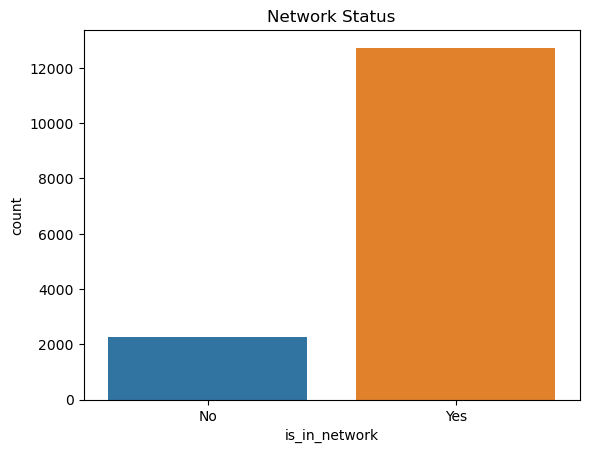

In [15]:
#Network Status Analysis
sns.countplot(x='is_in_network', data=ds)
plt.title("Network Status")
plt.show()

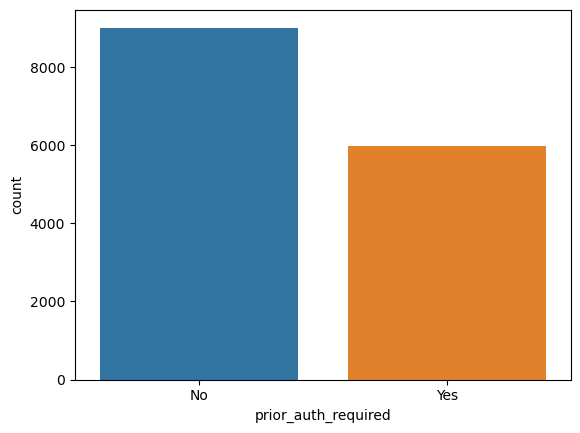

In [16]:
sns.countplot(x='prior_auth_required', data=ds)
plt.show()

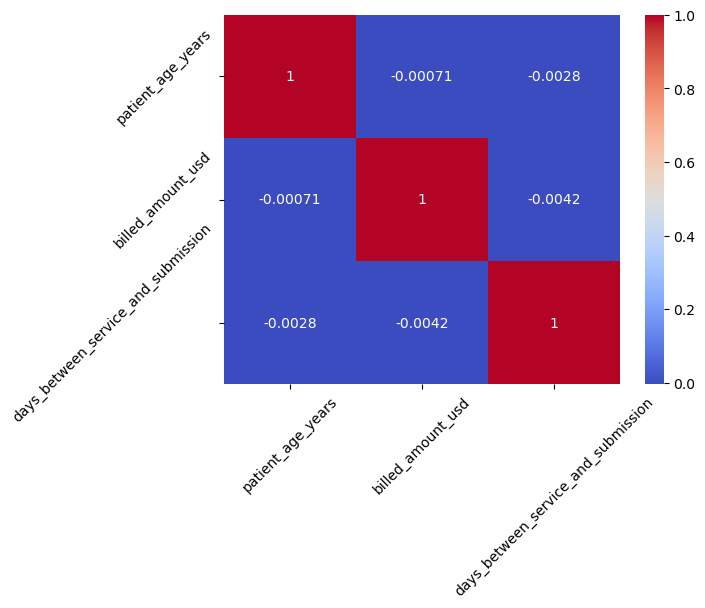

In [17]:
#Correlation Analysis
corr = ds[['patient_age_years',
           'billed_amount_usd',
           'days_between_service_and_submission']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.show()

In [18]:
ds.to_csv('user_input_data.csv', index=False)

In [19]:
#Label encoding for conversion

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

ds['patient_gender'] = le.fit_transform(ds['patient_gender'])

ds['is_in_network'] = ds['is_in_network'].map({'Yes':1,'No':0})

ds['prior_auth_required'] = ds['prior_auth_required'].map({'Yes':1,'No':0})

In [20]:
x = ds.drop(['claim_id','claim_status','denial_reason_code'], axis=1)

y = ds['claim_status']

In [21]:
x

,patient_age_years,patient_gender,payer_id,insurance_plan_type,is_in_network,procedure_code_cpt,primary_diagnosis_code_icd10,provider_specialty,facility_type,prior_auth_required,billed_amount_usd,days_between_service_and_submission,prior_auth_status
0,49,1,PAYER_B,HMO,0,99214,F32.9,Orthopedic Surgery,Skilled Nursing Facility,0,247.60,109,Not Required
1,24,0,PAYER_B,POS,1,93000,F32.9,Cardiology,Outpatient Clinic,1,219.21,75,Denied
2,67,1,PAYER_D,EPO,1,93000,N39.0,Internal Medicine,Ambulatory Surgery Center,1,1334.56,107,Approved
3,87,0,PAYER_C,PPO,1,99213,N39.0,Oncology,Emergency Room,1,2593.11,108,Approved
4,73,0,PAYER_A,HMO,1,99214,E11.9,Oncology,Inpatient Hospital,0,6082.16,155,Not Required
...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,15,0,PAYER_C,POS,1,29881,F32.9,Radiology,Ambulatory Surgery Center,0,556.11,30,Not Required
14996,42,1,PAYER_D,PPO,1,36415,Z00.00,Oncology,Emergency Room,0,2687.50,126,Not Required
14997,98,0,PAYER_B,PPO,0,71045,F32.9,Radiology,Skilled Nursing Facility,0,520.63,130,Not Required
14998,99,0,PAYER_C,PPO,0,99214,M54.5,Cardiology,Outpatient Clinic,0,4609.24,21,Not Required


In [22]:
y

0        1
1        1
2        0
3        0
4        0
        ..
14995    0
14996    0
14997    1
14998    0
14999    1
Name: claim_status, Length: 15000, dtype: int64

In [23]:
x['insurance_plan_type'].value_counts()

insurance_plan_type
EPO     3047
POS     3046
HMO     2989
PPO     2964
HDHP    2954
Name: count, dtype: int64

In [24]:
x['procedure_code_cpt'].value_counts()

procedure_code_cpt
71045    1942
93000    1929
29881    1912
99283    1887
99214    1856
G0439    1846
99213    1821
36415    1807
Name: count, dtype: int64

In [25]:
x['primary_diagnosis_code_icd10'].value_counts()

primary_diagnosis_code_icd10
F32.9      1933
Z00.00     1902
R05        1895
J45.909    1891
N39.0      1869
E11.9      1855
I10        1852
M54.5      1803
Name: count, dtype: int64

In [26]:
# One-hot encoding for categorical columns
x = pd.get_dummies(x, columns=[
    'payer_id',
    'insurance_plan_type',
    'procedure_code_cpt',
    'primary_diagnosis_code_icd10',
    'provider_specialty',
    'facility_type',
    'prior_auth_status'
], drop_first=True)

In [27]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [28]:
from imblearn.over_sampling import SMOTE
# Now run your SMOTE code
smote = SMOTE(random_state=42)
x_train_res, y_train_res = smote.fit_resample(x_train, y_train)

print("Original class counts:", np.bincount(y_train))
print("Resampled class counts:", np.bincount(y_train_res))

Original class counts: [8497 3503]
Resampled class counts: [8497 8497]


In [29]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler() 

X_train_scaled = scaler.fit_transform(x_train_res)
X_test_scaled = scaler.transform(x_test)

In [30]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report,ConfusionMatrixDisplay, \
                            precision_score, recall_score, f1_score, roc_auc_score,roc_curve 

In [31]:
models={
    "Logisitic Regression":LogisticRegression(),
    "Decision Tree":DecisionTreeClassifier(max_depth=6, min_samples_leaf=20),
    "Random Forest":RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=5,
    random_state=42),
    "KNN":KNeighborsClassifier()
}
for name, model in models.items():
    print(name)   

    if name in ["Logisitic Regression","KNN"]:
        model.fit(X_train_scaled, y_train_res)

        y_train_pred = model.predict(X_train_scaled)
        y_test_pred = model.predict(X_test_scaled)

    else:
        model.fit(x_train_res, y_train_res)

        y_train_pred = model.predict(x_train_res)
        y_test_pred = model.predict(x_test)

    # Training performance
    model_train_accuracy = accuracy_score(y_train_res, y_train_pred)
    model_train_f1 = f1_score(y_train_res, y_train_pred, average='weighted')
    model_train_precision = precision_score(y_train_res, y_train_pred)
    model_train_recall = recall_score(y_train_res, y_train_pred)
    model_train_rocauc_score = roc_auc_score(y_train_res, y_train_pred)

    # Test performance
    model_test_accuracy = accuracy_score(y_test, y_test_pred)
    model_test_f1 = f1_score(y_test, y_test_pred, average='weighted')
    model_test_precision = precision_score(y_test, y_test_pred)
    model_test_recall = recall_score(y_test, y_test_pred)
    model_test_rocauc_score = roc_auc_score(y_test, y_test_pred)

    
    print('Model performance for Training set')
    print("- Accuracy: {:.4f}".format(model_train_accuracy))
    print('- F1 score: {:.4f}'.format(model_train_f1))
    
    print('- Precision: {:.4f}'.format(model_train_precision))
    print('- Recall: {:.4f}'.format(model_train_recall))
    print('- Roc Auc Score: {:.4f}'.format(model_train_rocauc_score))

    
    
    print('----------------------------------')
    
    print('Model performance for Test set')
    print('- Accuracy: {:.4f}'.format(model_test_accuracy))
    print('- F1 score: {:.4f}'.format(model_test_f1))
    print('- Precision: {:.4f}'.format(model_test_precision))
    print('- Recall: {:.4f}'.format(model_test_recall))
    print('- Roc Auc Score: {:.4f}'.format(model_test_rocauc_score))

    
    print('='*35)
    print('\n')

Logisitic Regression
Model performance for Training set
- Accuracy: 0.8765
- F1 score: 0.8765
- Precision: 0.8942
- Recall: 0.8542
- Roc Auc Score: 0.8765
----------------------------------
Model performance for Test set
- Accuracy: 0.8297
- F1 score: 0.8278
- Precision: 0.7327
- Recall: 0.6815
- Roc Auc Score: 0.7874


Decision Tree
Model performance for Training set
- Accuracy: 0.8568
- F1 score: 0.8550
- Precision: 0.9566
- Recall: 0.7474
- Roc Auc Score: 0.8568
----------------------------------
Model performance for Test set
- Accuracy: 0.8673
- F1 score: 0.8597
- Precision: 0.8973
- Recall: 0.6304
- Roc Auc Score: 0.7997


Random Forest
Model performance for Training set
- Accuracy: 0.9147
- F1 score: 0.9143
- Precision: 0.9826
- Recall: 0.8444
- Roc Auc Score: 0.9147
----------------------------------
Model performance for Test set
- Accuracy: 0.8660
- F1 score: 0.8574
- Precision: 0.9097
- Recall: 0.6149
- Roc Auc Score: 0.7943


KNN
Model performance for Training set
- Accurac

In [32]:
import pickle

In [33]:
import pickle
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

models = {
    "Decision Tree": DecisionTreeClassifier(max_depth=6, min_samples_leaf=20),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        min_samples_leaf=5,
        random_state=42
    ),
    "KNN": KNeighborsClassifier()
}

for name, model in models.items():
    print(name)

    # KNN needs scaled data
    if name == "KNN":
        model.fit(X_train_scaled, y_train_res)

        y_train_pred = model.predict(X_train_scaled)
        y_test_pred = model.predict(X_test_scaled)

    else:
        model.fit(x_train_res, y_train_res)

        y_train_pred = model.predict(x_train_res)
        y_test_pred = model.predict(x_test)

    # ✅ Save model as pickle file
    filename = name.replace(" ", "_") + ".pkl"

    with open(filename, "wb") as file:
        pickle.dump(model, file)

    print(f"{name} model saved as {filename}")
    print("=" * 35)

Decision Tree
Decision Tree model saved as Decision_Tree.pkl
Random Forest
Random Forest model saved as Random_Forest.pkl
KNN
KNN model saved as KNN.pkl


In [34]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test,y_test_pred))

[[1981  118]
 [ 535  366]]


In [35]:
from sklearn.model_selection import GridSearchCV
param_grid = {'n_estimators': [100, 200], 'max_depth': [10, 20, None]}
grid_search = GridSearchCV(RandomForestClassifier(), param_grid, cv=3)
grid_search.fit(x_train_res, y_train_res)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [10, 20, ...], 'n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the f

In [36]:
best_model = grid_search.best_estimator_
best_model

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [37]:
grid_pred = grid_search.predict(x_test)

In [38]:
grid_pred

array([0, 0, 0, ..., 1, 1, 0], dtype=int64)

In [39]:
print(classification_report(y_test,grid_pred))

              precision    recall  f1-score   support

           0       0.86      0.97      0.91      2099
           1       0.89      0.62      0.73       901

    accuracy                           0.86      3000
   macro avg       0.87      0.80      0.82      3000
weighted avg       0.87      0.86      0.86      3000



In [40]:
print(confusion_matrix(y_test,grid_pred))

[[2030   69]
 [ 338  563]]


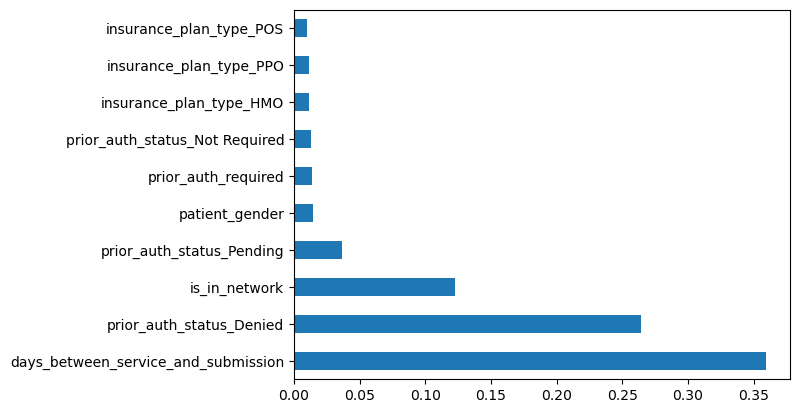

In [41]:
#Feature Importance: See which of those 40 columns actually matters.
import matplotlib.pyplot as plt
feat_importances = pd.Series(models['Random Forest'].feature_importances_, index=x.columns)
feat_importances.nlargest(10).plot(kind='barh')
plt.show()

In [42]:
results = pd.DataFrame({
    "Actual_Class": y_test.reset_index(drop=True)
})

for name, model in models.items():

    if name in ["Logisitic Regression", "KNN"]:
        model.fit(X_train_scaled, y_train_res)
        probs = model.predict_proba(X_test_scaled)[:,1]

    else:
        model.fit(x_train_res, y_train_res)
        probs = model.predict_proba(x_test)[:,1]

    # convert to percentage
    results[name + "_Denial_Prob_%"] = (probs * 100).round(2)

results.head(10)

,Actual_Class,Decision Tree_Denial_Prob_%,Random Forest_Denial_Prob_%,KNN_Denial_Prob_%
0,0,0.00,5.82,0.0
1,0,0.00,8.46,20.0
2,0,0.00,23.31,40.0
3,1,48.44,44.41,20.0
4,1,100.00,85.57,60.0
5,0,0.00,6.59,0.0
6,0,0.00,5.63,0.0
7,0,38.16,44.28,20.0
8,0,0.00,5.99,20.0
9,0,0.00,5.45,20.0


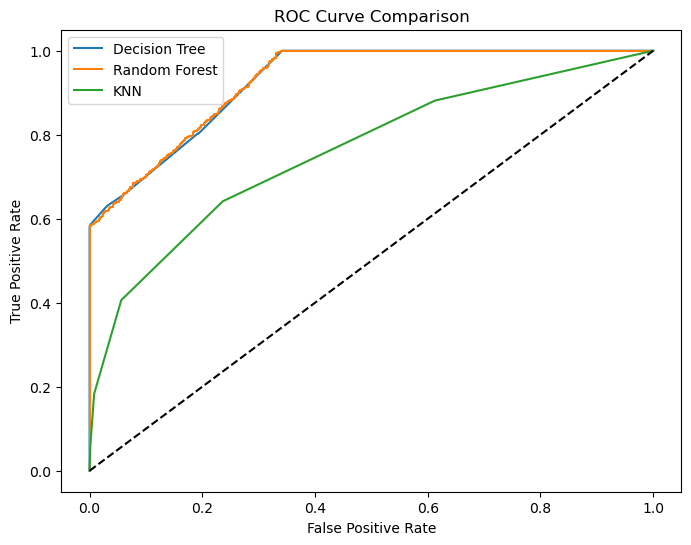

In [43]:
plt.figure(figsize=(8,6))

for name, model in models.items():

    if name in ["Logisitic Regression","KNN"]:
        probs = model.predict_proba(X_test_scaled)[:,1]
    else:
        probs = model.predict_proba(x_test)[:,1]

    fpr, tpr, _ = roc_curve(y_test, probs)

    plt.plot(fpr, tpr, label=name)

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.show()

In [44]:
actual_vs_pred = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_test_pred
})

actual_vs_pred.head(20)

,Actual,Predicted
0,0,0
1,0,0
2,0,0
3,1,0
4,1,1
5,0,0
6,0,0
7,0,0
8,0,0
9,0,0


In [45]:
actual_vs_pred["Result"] = np.where(actual_vs_pred["Actual"] == actual_vs_pred["Predicted"], "Correct", "Wrong")

actual_vs_pred.head(20)

,Actual,Predicted,Result
0,0,0,Correct
1,0,0,Correct
2,0,0,Correct
3,1,0,Wrong
4,1,1,Correct
5,0,0,Correct
6,0,0,Correct
7,0,0,Correct
8,0,0,Correct
9,0,0,Correct


In [46]:
actual_vs_pred["Result"].value_counts()

Result
Correct    2347
Wrong       653
Name: count, dtype: int64

In [47]:
# Get prediction probability
denial_prob = best_model.predict_proba(x_test)[:,1]

In [48]:
predictions = best_model.predict(x_test)

claim_status_output = np.where(predictions == 1, "Denied", "Accepted")

In [49]:
denial_reasons = ds.loc[y_test.index, "denial_reason_code"].values

In [50]:
results = pd.DataFrame({
    #"Claim_ID": ds.loc[y_test.index, "claim_id"].values,
    "Denial_Probability": (best_model.predict_proba(x_test)[:,1] * 100),
    "Denial_Reason": ds.loc[y_test.index, "denial_reason_code"].values
})

results.head()

,Denial_Probability,Denial_Reason
0,1.000000,NaN
1,1.554487,NaN
2,12.000000,NaN
3,38.756728,Timely Filing
4,97.000000,Lack of Prior Auth


In [51]:
threshold = 50   # probability threshold

for i in range(len(results)):

    prob = results.iloc[i]["Denial_Probability"]
    reason = results.iloc[i]["Denial_Reason"]

    if prob >= threshold:
        print("Claim Prediction: DENIED")
        print(f"Denial Probability: {prob:.2f}%")
        print("Possible Reason:", reason)
    else:
        print("Claim Prediction: APPROVED")
        print(f"Denial Probability: {prob:.2f}%")
        print("Possible Reason: None (Claim Approved)")

    print("----------------------")

Claim Prediction: APPROVED
Denial Probability: 1.00%
Possible Reason: None (Claim Approved)
----------------------
Claim Prediction: APPROVED
Denial Probability: 1.55%
Possible Reason: None (Claim Approved)
----------------------
Claim Prediction: APPROVED
Denial Probability: 12.00%
Possible Reason: None (Claim Approved)
----------------------
Claim Prediction: APPROVED
Denial Probability: 38.76%
Possible Reason: None (Claim Approved)
----------------------
Claim Prediction: DENIED
Denial Probability: 97.00%
Possible Reason: Lack of Prior Auth
----------------------
Claim Prediction: APPROVED
Denial Probability: 1.29%
Possible Reason: None (Claim Approved)
----------------------
Claim Prediction: APPROVED
Denial Probability: 1.12%
Possible Reason: None (Claim Approved)
----------------------
Claim Prediction: APPROVED
Denial Probability: 22.55%
Possible Reason: None (Claim Approved)
----------------------
Claim Prediction: APPROVED
Denial Probability: 0.14%
Possible Reason: None (Claim

In [52]:
# -------- CODE MEANINGS -------- #

procedure_map = {
    "29881": "Knee Arthroscopy Surgery",
    "36415": "Blood Draw (Venipuncture)",
    "71045": "Chest X-ray",
    "93000": "Electrocardiogram (ECG)",
    "99213": "Office Visit (Low Complexity)",
    "99214": "Office Visit (Moderate Complexity)",
    "99283": "Emergency Visit (Moderate Severity)",
    "G0439": "Annual Wellness Visit"
}

diagnosis_map = {
    "E11.9": "Type 2 Diabetes",
    "F32.9": "Depression",
    "I10": "Hypertension",
    "J45.909": "Asthma",
    "M54.5": "Back Pain",
    "N39.0": "Urinary Tract Infection",
    "R05": "Cough",
    "Z00.00": "General Health Check-up"
}

In [53]:
import pandas as pd
import numpy as np

# -------- VALID VALUES -------- #

valid_plans = ["EPO", "POS", "HMO", "PPO", "HDHP"]

procedure_map = {
    "29881": "Knee Arthroscopy Surgery",
    "36415": "Blood Draw (Venipuncture)",
    "71045": "Chest X-ray",
    "93000": "Electrocardiogram (ECG)",
    "99213": "Office Visit (Low Complexity)",
    "99214": "Office Visit (Moderate Complexity)",
    "99283": "Emergency Visit (Moderate Severity)",
    "G0439": "Annual Wellness Visit"
}

diagnosis_map = {
    "E11.9": "Type 2 Diabetes",
    "F32.9": "Depression",
    "I10": "Hypertension",
    "J45.909": "Asthma",
    "M54.5": "Back Pain",
    "N39.0": "Urinary Tract Infection",
    "R05": "Cough",
    "Z00.00": "General Health Check-up"
}

# -------- USER INPUT -------- #

age = int(input("Enter patient age: "))

if age <= 0:
    print("❌ Invalid Age: Age must be greater than 0")
    raise SystemExit

network = input("Is provider in network? (Yes/No): ")
prior_auth = input("Prior authorization required? (Yes/No): ")

billing = float(input("Enter billed amount: "))
delay = int(input("Days between service and submission: "))
plan = input("Enter insurance plan (EPO/POS/HMO/PPO/HDHP): ").upper()

procedure = input("Enter procedure code (e.g., 99213): ")
diagnosis = input("Enter diagnosis code (e.g., I10): ")

# -------- BASIC FEATURES -------- #

network_val = 1 if network.lower() == "yes" else 0
prior_auth_val = 1 if prior_auth.lower() == "yes" else 0

# -------- FEATURE VECTOR -------- #

user_data = pd.DataFrame(columns=x.columns)
user_data.loc[0] = 0

user_data['patient_age_years'] = age
user_data['is_in_network'] = network_val
user_data['prior_auth_required'] = prior_auth_val
user_data['billed_amount_usd'] = billing
user_data['days_between_service_and_submission'] = delay

plan_col = f"insurance_plan_type_{plan}"
if plan_col in user_data.columns:
    user_data[plan_col] = 1

proc_col = f"procedure_code_cpt_{procedure}"
if proc_col in user_data.columns:
    user_data[proc_col] = 1

diag_col = f"primary_diagnosis_code_icd10_{diagnosis}"
if diag_col in user_data.columns:
    user_data[diag_col] = 1

# -------- PREDICTION -------- #

prob = best_model.predict_proba(user_data)[0][1] * 100

# -------- EXPLANATION -------- #

reasons = []
force_denied = False

# Network
if network_val == 0:
    reasons.append("Provider is out-of-network")

# 🔥 UPDATED LOGIC (IMPORTANT)
if prior_auth.lower() == "no":
    reasons.append("Prior authorization required")
    force_denied = True  # 🚨 ALWAYS DENIED

# Delay
if delay > 30:
    reasons.append("Late claim submission")

# Billing
if billing > 10000:
    reasons.append("High billed amount")

# Invalid Plan
if plan not in valid_plans:
    reasons.append("Invalid insurance policy type")
    force_denied = True

# Invalid Procedure
if procedure not in procedure_map:
    reasons.append("Invalid procedure code")
    force_denied = True

# Invalid Diagnosis
if diagnosis not in diagnosis_map:
    reasons.append("Invalid diagnosis code")
    force_denied = True

# Mismatch
mismatch_pairs = [
    ("29881", "R05"),
    ("71045", "M54.5")
]

if (procedure, diagnosis) in mismatch_pairs:
    reasons.append("Procedure and diagnosis mismatch")

# Combine
system_reason = ", ".join(reasons) if reasons else "All claim conditions are appropriate"

# -------- FINAL REASON -------- #

if "invalid insurance" in system_reason.lower():
    final_reason = "Incorrect insurance policy selected"
elif "invalid procedure" in system_reason.lower():
    final_reason = "Procedure code is invalid"
elif "invalid diagnosis" in system_reason.lower():
    final_reason = "Diagnosis code is invalid"
elif "authorization" in system_reason.lower():
    final_reason = "Authorization missing"
elif "out-of-network" in system_reason.lower():
    final_reason = "Out-of-network services not covered"
elif "late" in system_reason.lower():
    final_reason = "Claim submitted after allowed time"
elif "mismatch" in system_reason.lower():
    final_reason = "Procedure does not match diagnosis"
elif "high billed amount" in system_reason.lower():
    final_reason = "High billing amount flagged"
else:
    final_reason = "No issues detected"

# -------- FINAL DECISION -------- #

risk_score = len(reasons)

if force_denied:
    status = "DENIED"
    prob = max(prob, 90)

elif risk_score >= 3:
    status = "DENIED"
    prob = max(prob, 80)

elif risk_score == 2:
    status = "RISK OF DENIAL"
    prob = max(prob, 50)

else:
    if prob >= 70:
        status = "DENIED"
    elif prob >= 40:
        status = "RISK OF DENIAL"
    else:
        status = "APPROVED"

# -------- REPORT -------- #

print("\n================= CLAIM ANALYSIS REPORT =================")

print("\n--- Patient Details ---")
print(f"Age: {age}")
print(f"In Network: {network}")
print(f"Prior Authorization: {prior_auth}")

print("\n--- Financial Details ---")
print(f"Billed Amount: ${billing}")
print(f"Submission Delay: {delay} days")
print(f"Insurance Plan: {plan}")

print("\n--- Medical Details ---")

proc_meaning = procedure_map.get(procedure, "Invalid Procedure Code")
diag_meaning = diagnosis_map.get(diagnosis, "Invalid Diagnosis Code")

print(f"Procedure: {procedure} → {proc_meaning}")
print(f"Diagnosis: {diagnosis} → {diag_meaning}")

print("\n--- Prediction ---")
print(f"Claim Status: {status}")
print(f"Denial Probability: {round(prob,2)}%")

print("\n--- Explanation ---")
print(f"System Insight: {system_reason}")

if status == "APPROVED":
    print("Possible Denial Reason: None (Claim Approved)")
else:
    print(f"Possible Denial Reason: {final_reason}")

print("\n=========================================================")

Enter patient age: 89
Is provider in network? (Yes/No): no
Prior authorization required? (Yes/No): no
Enter billed amount: 790
Days between service and submission: 6
Enter insurance plan (EPO/POS/HMO/PPO/HDHP): ppo
Enter procedure code (e.g., 99213): 99213
Enter diagnosis code (e.g., I10): I10

================= CLAIM ANALYSIS REPORT =================

--- Patient Details ---
Age: 89
In Network: no
Prior Authorization: no

--- Financial Details ---
Billed Amount: $790.0
Submission Delay: 6 days
Insurance Plan: PPO

--- Medical Details ---
Procedure: 99213 → Office Visit (Low Complexity)
Diagnosis: I10 → Hypertension

--- Prediction ---
Claim Status: DENIED
Denial Probability: 90%

--- Explanation ---
System Insight: Provider is out-of-network, Prior authorization required
Possible Denial Reason: Authorization missing



In [58]:
import pickle

# -------- SAVE MODEL -------- #
with open("model.pkl", "wb") as f:
    pickle.dump(best_model, f)

# -------- SAVE LABEL ENCODER -------- #
with open("label_encoder.pkl", "wb") as f:
    pickle.dump(le, f)

# -------- SAVE SCALER -------- #
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

# -------- SAVE FEATURE COLUMNS (VERY IMPORTANT) -------- #
with open("columns.pkl", "wb") as f:
    pickle.dump(x.columns.tolist(), f)

print("✅ model.pkl saved")
print("✅ label_encoder.pkl saved")
print("✅ scaler.pkl saved")
print("✅ columns.pkl saved")

✅ model.pkl saved
✅ label_encoder.pkl saved
✅ scaler.pkl saved
✅ columns.pkl saved
